
# Demo Tuần 4 - Visual Search Retrieval

Notebook demo chuẩn theo yêu cầu:

```python
query_path = 'sample_query.jpg'
top5 = search(query_path, index, candidate_df, IMAGE_DIR, k=5)
show_top5(top5)
```

Cách dùng nhanh:

1. Đặt `sample_query.jpg` cùng thư mục với notebook, hoặc sửa biến `query_path` thành đường dẫn ảnh trong `data/raw/train_images`.
2. Chạy cell bên dưới.
3. Kết quả Top-5 được hiển thị và lưu vào `results/demo_top5_result.csv`.

Ghi chú: Demo ưu tiên dùng `top_indices` đã được tạo bởi phương pháp chính Strong Fusion. Nếu ảnh query không nằm trong `candidate_df`, notebook sẽ dùng fallback pHash để vẫn có kết quả minh họa, nhưng kết quả chuẩn nhất là dùng ảnh thuộc tập candidate/train.


PROJECT_ROOT: e:\study\DoAnPython\project\notebooks\Nhom3thangcuti_Tuan4\demo
RESULTS_DIR : e:\study\DoAnPython\project\notebooks\Nhom3thangcuti_Tuan4\demo\..\results
✅ top_indices NPY: e:\study\DoAnPython\project\notebooks\Nhom3thangcuti_Tuan4\data\processed\STRONG_best_top_indices_StrongFusion_global_crop_text_light_crop_phash_strong.npy
✅ candidate_df CSV dùng manual: E:\study\DoAnPython\project\data\processed\candidate_df_strong_yolo_crop_fusion.csv
✅ IMAGE_DIR dùng manual: E:\study\DuLieuPython\data\raw\train_images
candidate_df: (34250, 6)
index/top_indices: (34250, 10)
⚠️ Chưa thấy sample_query.jpg, tạm dùng ảnh mẫu trong candidate_df: E:\study\DuLieuPython\data\raw\train_images\8c79f5e57737e712428b009f3b811b29.jpg


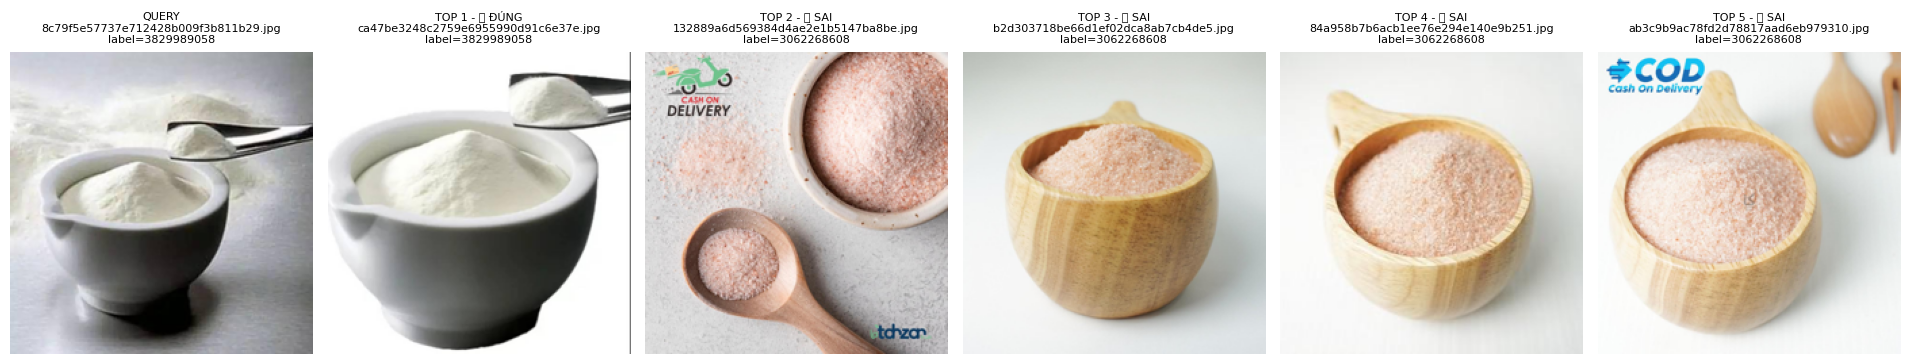


Bảng Top-5:


,rank,method,match_mode,result_image,result_label,is_correct
0,1,main_top_indices,filename_match,ca47be3248c2759e6955990d91c6e37e.jpg,3829989058,True
1,2,main_top_indices,filename_match,132889a6d569384d4ae2e1b5147ba8be.jpg,3062268608,False
2,3,main_top_indices,filename_match,b2d303718be66d1ef02dca8ab7cb4de5.jpg,3062268608,False
3,4,main_top_indices,filename_match,84a958b7b6acb1ee76e294e140e9b251.jpg,3062268608,False
4,5,main_top_indices,filename_match,ab3c9b9ac78fd2d78817aad6eb979310.jpg,3062268608,False


✅ Đã lưu: e:\study\DoAnPython\project\notebooks\Nhom3thangcuti_Tuan4\demo\..\results\demo_top5_result.csv


In [1]:

# ============================================================
# Demo Tuần 4 - Visual Search Retrieval
# Lê Quốc Bảo
#
# Mục tiêu:
#   query_path = 'sample_query.jpg'
#   top5 = search(query_path, index, candidate_df, IMAGE_DIR, k=5)
#   show_top5(top5)
#
# Notebook này ưu tiên dùng output chính đã tính sẵn:
#   - candidate_df_strong_yolo_crop_fusion.csv
#   - STRONG_best_top_indices_*.npy
# Nếu query là ảnh trong candidate_df/train_images, kết quả lấy đúng từ top_indices của phương pháp chính.
# Nếu query là ảnh ngoài candidate_df, notebook fallback bằng pHash để demo vẫn chạy được.
# ============================================================

from pathlib import Path
from typing import Optional, List, Tuple
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from IPython.display import display

# ============================================================
# 1) CONFIG
# ============================================================
# Để trống để notebook tự tìm file trong project.
# Nếu tự tìm không được, điền đường dẫn thủ công vào đây.
MANUAL_TOP_NPY = r"E:\study\DoAnPython\project\data\processed\STRONG_best_top_indices_xxx.npy"
MANUAL_CANDIDATE_CSV = r"E:\study\DoAnPython\project\data\processed\candidate_df_strong_yolo_crop_fusion.csv"
MANUAL_IMAGE_DIR = r"E:\study\DuLieuPython\data\raw\train_images"

# File query demo. Có thể upload/copy ảnh vào cùng thư mục notebook và đặt tên sample_query.jpg.
query_path = "demo/sample_query.jpg"
K = 5
SAVE_DEMO_CSV = True
ALLOW_PHASH_FALLBACK_FOR_EXTERNAL_IMAGE = True

PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "../results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_DIR :", RESULTS_DIR)

# ============================================================
# 2) TÌM FILE OUTPUT CỦA PIPELINE
# ============================================================
def existing_path(p: str) -> Optional[Path]:
    if p is None or str(p).strip() == "":
        return None
    path = Path(p)
    return path if path.exists() else None


def unique_existing_dirs(dirs: List[Path]) -> List[Path]:
    out, seen = [], set()
    for d in dirs:
        d = Path(d)
        if not d.exists():
            continue
        try:
            key = str(d.resolve())
        except Exception:
            key = str(d)
        if key not in seen:
            seen.add(key)
            out.append(d)
    return out

# Tìm rộng lên nhiều cấp cha để tránh hard-code kiểu E:\... rồi qua máy khác chết như phim kinh dị.
ROOT_CANDIDATES = [PROJECT_ROOT] + list(PROJECT_ROOT.parents[:6])
SEARCH_DIRS = []
for root in ROOT_CANDIDATES:
    SEARCH_DIRS += [
        root,
        root / "results",
        root / "data" / "processed",
        root / "outputs",
        root / "outputs_twostage_gpu",
        root / "outputs" / "tuan4_two_stage",
    ]
SEARCH_DIRS = unique_existing_dirs(SEARCH_DIRS)


def find_latest(patterns: List[str], manual_path: str = "", required: bool = True, name: str = "file") -> Optional[Path]:
    manual = existing_path(manual_path)
    if manual is not None:
        print(f"✅ {name} dùng manual:", manual)
        return manual

    matches = []
    for base in SEARCH_DIRS:
        for pattern in patterns:
            try:
                matches.extend([p for p in base.glob(pattern) if p.is_file()])
            except Exception:
                pass

    unique = {}
    for p in matches:
        try:
            unique[str(p.resolve())] = p
        except Exception:
            unique[str(p)] = p
    matches = list(unique.values())

    if not matches:
        msg = f"Không tìm thấy {name}. Hãy sửa MANUAL_* ở phần CONFIG."
        if required:
            raise FileNotFoundError(msg)
        print("⚠️", msg)
        return None

    matches = sorted(matches, key=lambda p: p.stat().st_mtime, reverse=True)
    print(f"✅ {name}:", matches[0])
    if len(matches) > 1:
        print(f"   Tìm thấy {len(matches)} file, chọn file mới nhất.")
    return matches[0]


TOP_NPY = find_latest(
    patterns=[
        "**/STRONG_best_top_indices_*.npy",
        "**/FINAL_fusion_resnet_tfidf_top_indices_*.npy",
        "**/*top_indices*.npy",
        "**/*top_idx*.npy",
    ],
    manual_path=MANUAL_TOP_NPY,
    required=True,
    name="top_indices NPY",
)

CANDIDATE_CSV = find_latest(
    patterns=[
        "**/candidate_df_strong_yolo_crop_fusion.csv",
        "**/candidate_df_twostage_yolo_sahi_effb4_tfidf.csv",
        "**/candidate_df_resnet_tfidf_fusion.csv",
        "**/candidate_df*.csv",
    ],
    manual_path=MANUAL_CANDIDATE_CSV,
    required=True,
    name="candidate_df CSV",
)


def find_image_dir(manual_path: str = "") -> Optional[Path]:
    manual = existing_path(manual_path)
    if manual is not None and manual.is_dir():
        print("✅ IMAGE_DIR dùng manual:", manual)
        return manual

    candidates = []
    for root in ROOT_CANDIDATES:
        candidates += [
            root / "data" / "raw" / "train_images",
            root / "project" / "data" / "raw" / "train_images",
        ]
    candidates += [
        Path(CANDIDATE_CSV).parent.parent / "raw" / "train_images",
        Path(CANDIDATE_CSV).parent.parent.parent / "raw" / "train_images",
    ]

    for c in candidates:
        if c.exists() and c.is_dir():
            print("✅ IMAGE_DIR:", c)
            return c

    print("⚠️ Chưa tìm thấy IMAGE_DIR. Nếu candidate_df có image_path hợp lệ thì vẫn chạy được.")
    return None


IMAGE_DIR = find_image_dir(MANUAL_IMAGE_DIR)

# ============================================================
# 3) LOAD VÀ CHUẨN HÓA DỮ LIỆU
# ============================================================
candidate_df = pd.read_csv(CANDIDATE_CSV)
index = np.load(TOP_NPY)  # giữ tên index đúng format demo yêu cầu

print("candidate_df:", candidate_df.shape)
print("index/top_indices:", index.shape)

if "image" not in candidate_df.columns:
    if "image_name" in candidate_df.columns:
        candidate_df["image"] = candidate_df["image_name"]
    elif "posting_id" in candidate_df.columns:
        candidate_df["image"] = candidate_df["posting_id"].astype(str)
    else:
        raise ValueError("candidate_df thiếu cột image / image_name / posting_id.")

if "label_group" not in candidate_df.columns:
    candidate_df["label_group"] = "unknown"
    print("⚠️ candidate_df thiếu label_group, demo vẫn chạy nhưng không đánh dấu đúng/sai được.")

if index.shape[0] != len(candidate_df):
    raise ValueError(
        f"top_indices lệch candidate_df: index có {index.shape[0]} dòng, "
        f"candidate_df có {len(candidate_df)} dòng. Sửa TOP_NPY hoặc CANDIDATE_CSV."
    )


def resolve_image_path_from_row(row) -> str:
    if "image_path" in row and pd.notna(row["image_path"]):
        p = Path(str(row["image_path"]))
        if p.exists():
            return str(p)

    name = str(row["image"])
    candidates = []
    if IMAGE_DIR is not None:
        candidates += [IMAGE_DIR / name, IMAGE_DIR / Path(name).name]

    for root in ROOT_CANDIDATES:
        candidates += [
            root / name,
            root / "data" / "raw" / "train_images" / Path(name).name,
        ]

    for p in candidates:
        if p.exists():
            return str(p)

    return str(row.get("image_path", name))


candidate_df["resolved_image_path"] = candidate_df.apply(resolve_image_path_from_row, axis=1)
candidate_df["image_basename"] = candidate_df["image"].astype(str).map(lambda x: Path(x).name)

# ============================================================
# 4) HÀM XỬ LÝ ẢNH + pHASH KHÔNG CẦN THƯ VIỆN NGOÀI
# ============================================================
def load_rgb(path, size: Optional[Tuple[int, int]] = None) -> Image.Image:
    img = Image.open(path).convert("RGB")
    img = ImageOps.exif_transpose(img)
    if size is not None:
        img = img.resize(size)
    return img


def phash_hex(path, hash_size: int = 8, highfreq_factor: int = 4) -> str:
    """Tính perceptual hash gần tương thích imagehash.phash, tránh phụ thuộc thư viện ngoài."""
    img_size = hash_size * highfreq_factor
    img = load_rgb(path, size=(img_size, img_size)).convert("L")
    pixels = np.asarray(img, dtype=np.float32)

    n = img_size
    x = np.arange(n)
    u = np.arange(n).reshape(-1, 1)
    basis = np.cos(((2 * x + 1) * u * np.pi) / (2 * n))
    dct = basis @ pixels @ basis.T
    low = dct[:hash_size, :hash_size]

    # Bỏ hệ số DC để median ổn định hơn.
    med = np.median(low.flatten()[1:])
    bits = (low > med).flatten()

    value = 0
    for bit in bits:
        value = (value << 1) | int(bit)
    return f"{value:0{hash_size * hash_size // 4}x}"


def hex_hamming(a, b) -> int:
    try:
        return (int(str(a), 16) ^ int(str(b), 16)).bit_count()
    except Exception:
        return 999


def resolve_query_path(path_like) -> Path:
    p = Path(path_like)
    candidates = [p, PROJECT_ROOT / p]
    if IMAGE_DIR is not None:
        candidates.append(IMAGE_DIR / p.name)

    for c in candidates:
        if c.exists() and c.is_file():
            return c

    raise FileNotFoundError(
        f"Không tìm thấy query image: {path_like}. "
        "Hãy đặt sample_query.jpg cùng thư mục notebook hoặc sửa query_path thành đường dẫn ảnh hợp lệ."
    )


def find_query_idx(query_path, candidate_df, image_dir=None, max_phash_distance: int = 4):
    """Tìm query trong candidate_df bằng filename/path/pHash."""
    q_path = resolve_query_path(query_path)
    q_name = q_path.name

    # 1) Match theo tên file.
    matches = np.where(candidate_df["image_basename"].astype(str).values == q_name)[0]
    if len(matches) > 0:
        return int(matches[0]), q_path, "filename_match"

    # 2) Match theo đường dẫn tuyệt đối nếu candidate_df có image_path.
    if "resolved_image_path" in candidate_df.columns:
        q_abs = str(q_path.resolve()).lower()
        paths = candidate_df["resolved_image_path"].astype(str).map(lambda x: str(Path(x)).lower())
        matches = np.where(paths.values == q_abs)[0]
        if len(matches) > 0:
            return int(matches[0]), q_path, "path_match"

    # 3) Match bằng pHash nếu candidate_df có sẵn image_phash.
    if "image_phash" in candidate_df.columns:
        q_hash = phash_hex(q_path)
        dists = candidate_df["image_phash"].astype(str).map(lambda h: hex_hamming(q_hash, h)).values
        best_idx = int(np.argmin(dists))
        best_dist = int(dists[best_idx])
        if best_dist <= max_phash_distance:
            return best_idx, q_path, f"phash_match_distance_{best_dist}"

    return None, q_path, "external_image_not_in_candidate_df"

# ============================================================
# 5) SEARCH + SHOW_TOP5 ĐÚNG FORMAT YÊU CẦU
# ============================================================
def search(query_path, index, candidate_df, IMAGE_DIR=None, k: int = 5) -> pd.DataFrame:
    q_idx, q_path, match_mode = find_query_idx(query_path, candidate_df, IMAGE_DIR)

    rows = []

    if q_idx is not None:
        # Chuẩn nhất: query nằm trong candidate_df, dùng top_indices của phương pháp chính.
        q_row = candidate_df.iloc[q_idx]
        seen_images = {str(q_row["image_basename"])}

        for idx in list(index[q_idx]):
            idx = int(idx)
            if idx < 0 or idx >= len(candidate_df) or idx == q_idx:
                continue

            r = candidate_df.iloc[idx]
            r_name = str(r["image_basename"])
            if r_name in seen_images:
                continue
            seen_images.add(r_name)

            rows.append({
                "rank": len(rows) + 1,
                "method": "main_top_indices",
                "match_mode": match_mode,
                "query_idx": q_idx,
                "result_idx": idx,
                "query_image": str(q_row["image"]),
                "result_image": str(r["image"]),
                "query_label": q_row.get("label_group", "unknown"),
                "result_label": r.get("label_group", "unknown"),
                "is_correct": bool(q_row.get("label_group", None) == r.get("label_group", None)),
                "query_path": str(q_path),
                "result_path": str(r["resolved_image_path"]),
            })

            if len(rows) >= k:
                break

    elif ALLOW_PHASH_FALLBACK_FOR_EXTERNAL_IMAGE and "image_phash" in candidate_df.columns:
        # Fallback để demo vẫn chạy khi upload ảnh ngoài candidate_df.
        # Đây KHÔNG phải kết quả Strong Fusion chuẩn, chỉ là minh họa gần đúng bằng pHash.
        q_hash = phash_hex(q_path)
        tmp = candidate_df.copy()
        tmp["phash_distance"] = tmp["image_phash"].astype(str).map(lambda h: hex_hamming(q_hash, h))
        tmp = tmp.sort_values("phash_distance").head(k)

        for _, r in tmp.iterrows():
            rows.append({
                "rank": len(rows) + 1,
                "method": "fallback_phash_external_query",
                "match_mode": match_mode,
                "query_idx": None,
                "result_idx": int(r.name),
                "query_image": Path(q_path).name,
                "result_image": str(r["image"]),
                "query_label": "external_unknown",
                "result_label": r.get("label_group", "unknown"),
                "is_correct": None,
                "query_path": str(q_path),
                "result_path": str(r["resolved_image_path"]),
                "phash_distance": int(r["phash_distance"]),
            })
    else:
        raise ValueError(
            "Ảnh query không nằm trong candidate_df và không thể fallback. "
            "Để demo đúng phương pháp chính, hãy dùng ảnh trong train_images/candidate_df."
        )

    if len(rows) == 0:
        raise ValueError("Không tạo được Top-K. Kiểm tra index/top_indices hoặc query image.")

    return pd.DataFrame(rows).head(k)


def show_top5(top5: pd.DataFrame):
    q_path = top5.iloc[0]["query_path"]
    n = len(top5) + 1
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 4.2))
    if n == 1:
        axes = [axes]

    q_img = load_rgb(q_path, size=(224, 224))
    q_title = f"QUERY\n{Path(q_path).name}"
    if "query_label" in top5.columns:
        q_title += f"\nlabel={top5.iloc[0]['query_label']}"
    axes[0].imshow(q_img)
    axes[0].set_title(q_title, fontsize=8)
    axes[0].axis("off")

    for col, (_, row) in enumerate(top5.iterrows(), start=1):
        img = load_rgb(row["result_path"], size=(224, 224))
        correct = row.get("is_correct", None)
        if correct is True:
            mark = "✅ ĐÚNG"
        elif correct is False:
            mark = "❌ SAI"
        else:
            mark = "?"

        axes[col].imshow(img)
        axes[col].set_title(
            f"TOP {int(row['rank'])} - {mark}\n{row['result_image']}\nlabel={row['result_label']}",
            fontsize=8,
        )
        axes[col].axis("off")

    plt.tight_layout()
    plt.show()

    display_cols = [
        "rank", "method", "match_mode", "result_image", "result_label", "is_correct"
    ]
    if "phash_distance" in top5.columns:
        display_cols.append("phash_distance")

    print("\nBảng Top-5:")
    display(top5[[c for c in display_cols if c in top5.columns]])

# ============================================================
# 6) RUN DEMO - ĐÚNG 3 DÒNG MẪU
# ============================================================
# Nếu chưa có sample_query.jpg, notebook tự dùng ảnh đầu tiên trong candidate_df để demo không bị chết.
# Khi nộp/demo thật, chỉ cần đặt sample_query.jpg vào cùng thư mục notebook.
if not (PROJECT_ROOT / query_path).exists() and not Path(query_path).exists():
    fallback_query = candidate_df.iloc[0]["resolved_image_path"]
    print("⚠️ Chưa thấy sample_query.jpg, tạm dùng ảnh mẫu trong candidate_df:", fallback_query)
    query_path = fallback_query

# 3 dòng này là phần demo chính cần show.
top5 = search(query_path, index, candidate_df, IMAGE_DIR, k=K)
show_top5(top5)

if SAVE_DEMO_CSV:
    out_csv = RESULTS_DIR / "demo_top5_result.csv"
    top5.to_csv(out_csv, index=False, encoding="utf-8-sig")
    print("✅ Đã lưu:", out_csv)
